## libs import

In [2]:
import sqlite3
import pandas as pd

## connection

In [3]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

In [4]:
first_10_rows_query = "SELECT * FROM pageviews LIMIT 10;"
first_10_rows = pd.io.sql.read_sql(first_10_rows_query, connection)
print("\nFirst 10 rows of the table 'pageviews':")
print(first_10_rows)


First 10 rows of the table 'pageviews':
   index      uid                    datetime
0      0  admin_1  2020-04-17 12:01:08.463179
1      1  admin_1  2020-04-17 12:01:23.743946
2      2  admin_3  2020-04-17 12:17:39.287778
3      3  admin_3  2020-04-17 12:17:40.001768
4      4  admin_1  2020-04-17 12:27:30.646665
5      5  admin_1  2020-04-17 12:35:44.884757
6      6  admin_1  2020-04-17 12:35:52.735016
7      7  admin_3  2020-04-17 12:36:21.401412
8      8  admin_3  2020-04-17 12:36:22.023355
9      9  admin_1  2020-04-17 13:55:19.129243


## query: get datetime from pageviews for users

In [5]:
query = """
SELECT datetime
FROM pageviews
WHERE uid LIKE 'user_%'; 
"""
df = pd.read_sql_query(query, connection)

In [6]:
df['date'] = pd.to_datetime(df['datetime']).dt.date

daily_visits = df.groupby('date').size()
daily_visits_df = daily_visits.reset_index(name='views')
daily_visits_df['date'] = pd.to_datetime(daily_visits_df['date'])

In [7]:
daily_visits_df.head()

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1


## Plot. Views per day

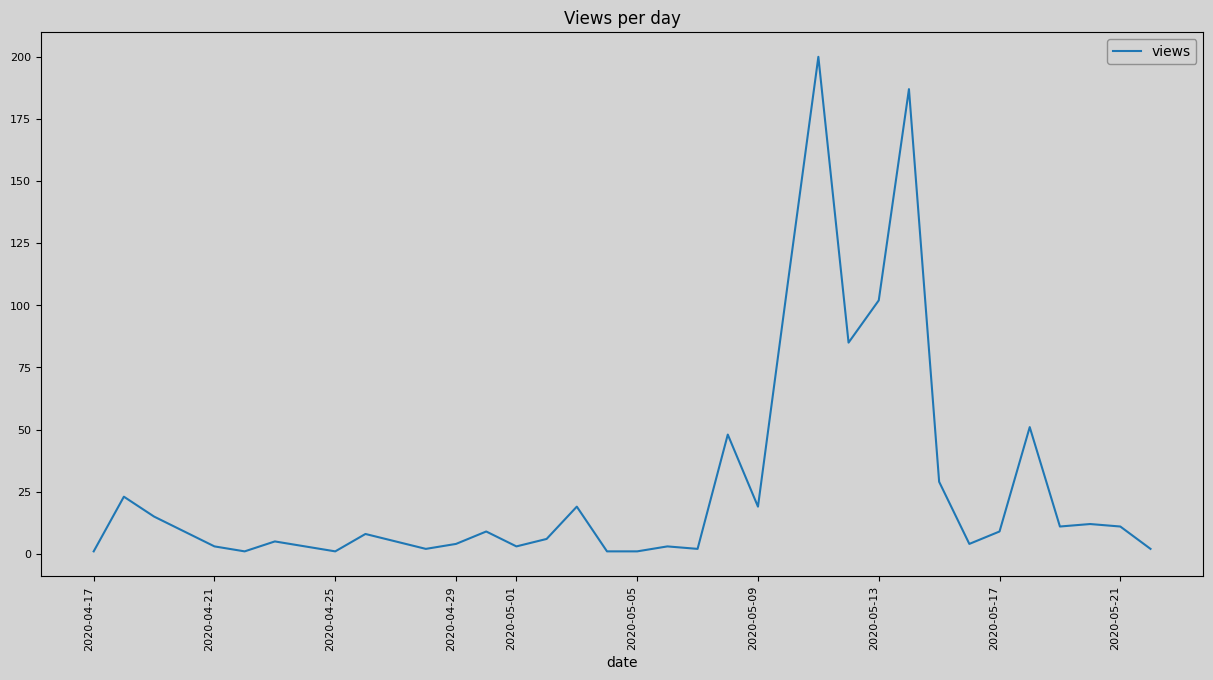

In [13]:
ax = daily_visits_df.plot(x='date', y='views', figsize=(15, 8), fontsize=8, title="Views per day")
ax.tick_params(axis='x', rotation=90)
ax.figure.set_facecolor('lightgray')
ax.set_facecolor('lightgray')
legend = ax.get_legend()
if legend:  # Проверяем, есть ли легенда
    legend.get_frame().set_facecolor('lightgray')  # Заливаем фон легенды серым
    legend.get_frame().set_edgecolor('gray')  # Устанавливаем цвет рамки легенды (опционально)

## connection close

In [14]:
connection.close()